<a href="https://colab.research.google.com/github/sergeyarefjev/jog_vkbot/blob/main/models/jog_bot_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import joblib

from sklearn.linear_model import LinearRegression, Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

from scipy.stats import skew, kurtosis, normaltest

import torch
import optuna

import xgboost as xgb

# Ковидный датасет

EDA в ноутбуке covid_intelligence

##Загрузка и мини-подготовка

In [ ]:
np.random.seed(42)

In [ ]:
data_path = "/content/drive/MyDrive/ML_data/jog_ml/ml_models/data_covid_2019_preprocessing.csv"
data = pd.read_csv(data_path).drop(columns=["country", "place"]).rename(columns={"datetime": "timestamp", "athlete" : "id"})
data.replace({"M": 1, "F": 0}, inplace=True)
data["timestamp"] = pd.to_datetime(data["timestamp"], format="%Y-%m-%d")

ohe = OneHotEncoder(sparse_output=False)
encoding = ohe.fit_transform(data["age_group"].values.reshape(-1, 1))
help_df = pd.DataFrame(encoding, columns=ohe.get_feature_names_out(), index=data.index)
data = pd.concat([data.drop(columns=["age_group"]), help_df], axis=1)
data.info()
#data = data.iloc[:int(0.5 * len(data))]

/tmp/ipykernel_1354/3868596155.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"M": 1, "F": 0}, inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3298051 entries, 0 to 3298050
Data columns (total 21 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   id                  int64         
 2   distance            float64       
 3   time_jog            float64       
 4   gender              int64         
 5   pace                float64       
 6   pace_lag_1          float64       
 7   pace_lag_2          float64       
 8   pace_lag_3          float64       
 9   pace_lag_4          float64       
 10  pace_lag_5          float64       
 11  pace_lag_6          float64       
 12  pace_lag_7          float64       
 13  pace_lag_8          float64       
 14  pace_lag_9          float64       
 15  pace_lag_10         float64       
 16  last_distance_pace  float64       
 17  last_time_jog_pace  float64       
 18  x0_18 - 34          float64       
 19  x0_35 - 54          float64       
 20  x0

In [ ]:
data.head()

,timestamp,id,distance,time_jog,gender,pace,pace_lag_1,pace_lag_2,pace_lag_3,pace_lag_4,...,pace_lag_6,pace_lag_7,pace_lag_8,pace_lag_9,pace_lag_10,last_distance_pace,last_time_jog_pace,x0_18 - 34,x0_35 - 54,x0_55 +
0,2019-01-12,125,13.28,61.000000,0,4.593373,4.594181,5.338680,4.885227,5.070132,...,4.805915,4.419431,5.131678,4.690619,4.732351,4.594181,4.594181,1.0,0.0,0.0
1,2019-01-12,247,5.90,30.133333,1,5.107345,5.678679,5.528053,5.878004,5.960286,...,5.468750,5.780952,6.131276,5.040266,5.711538,5.678679,5.678679,0.0,1.0,0.0
2,2019-01-12,931,1.68,10.133333,1,6.031746,5.670732,6.650407,5.047348,5.708583,...,7.765766,4.798517,6.423611,6.178161,5.664683,5.670732,5.670732,0.0,1.0,0.0
3,2019-01-12,1454,11.10,52.433333,1,4.723724,5.129991,4.197917,4.622871,4.565928,...,4.449810,4.722395,4.341801,4.216880,4.323995,5.129991,5.129991,0.0,1.0,0.0
4,2019-01-12,1700,5.04,21.933333,1,4.351852,4.750000,5.428393,5.964646,4.797222,...,5.274043,4.000000,4.693333,4.542593,4.824841,4.750000,4.750000,1.0,0.0,0.0


In [ ]:
def train_test_split_ts(model, df, test_percent, target="pace"):
    len_id = df.groupby("id")["gender"].count()
    data = df.sort_values(["id", "timestamp"]).copy()
    target_df = data[target]
    data.drop(columns=[target], inplace=True)
    x_train_list = []
    x_test_list = []
    y_train_list = []
    y_test_list = []
    i = 0
    while i < len(data):
        train_step = int((1 - test_percent) * len_id[data["id"].iloc[i]])
        next_step = len_id[data["id"].iloc[i]]
        x_train_list.append(data[i:i + train_step])
        x_test_list.append(data[i + train_step: i + next_step])
        y_train_list.append(target_df[i:i + train_step])
        y_test_list.append(target_df[i + train_step: i + next_step])

        i += next_step


    x_train = pd.concat(x_train_list, axis=0).drop(columns=["id", "timestamp"]).values
    x_test = pd.concat(x_test_list, axis=0).drop(columns=["id", "timestamp"]).values

    y_train = pd.concat(y_train_list, axis=0).values
    y_test = pd.concat(y_test_list, axis=0).values


    model.fit(x_train, y_train)
    predict = model.predict(x_test)
    rmse = root_mean_squared_error(y_test, predict)
    mae = mean_absolute_error(y_test, predict)
    r2 = r2_score(y_true=y_test, y_pred=predict)

    return predict, y_test, rmse, mae, r2

In [ ]:
def check_predict(y_test, predict):
    residuals = y_test - predict
    plt.title("Распределение остатков модели (true - predict)")
    plt.hist(residuals, bins=100)
    mean = residuals.mean()
    std = residuals.std()
    left_sigma = mean - std
    right_sigma = mean + std
    print(f"Процент заключенный в 1 сигме {np.sum(np.where(np.abs(residuals - mean) < std, 1, 0)) / len(residuals) * 100:.3f}")
    print(f"Среднее остатков: {mean:.3f}\nСтандартное отклонение остатков: {std:.3f}")
    plt.axvline(x=left_sigma, color='r', linestyle='--')
    plt.axvline(x=right_sigma, color='r', linestyle='--')

    print(f"Коэффициент ассиметрии: {kurtosis(residuals):.3f}")
    print(f"Коэффициент эксцесса: {skew(residuals):.3f}")
    #До нормального распределения далеко, но все же можно попробовать тест на нормальность (тест Пирсона) на уровне значимости alpha=0.05
    result = normaltest(residuals)
    print(f"P-value теста Пирсона: {result.pvalue:.3f}")

In [ ]:
def visual_model_predict(model, data):
    pred, y_test, rmse, mae, r2 = train_test_split_ts(model, data, test_percent=test_percent, target="pace")

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R\u00B2 {r2:.4f}")
    check_predict(y_test, pred)

In [ ]:
test_percent = 0.05

##Ridge регрессия

Вообще как видно из подбора, особо не важно какой alpha брать

RMSE: 0.7795
MAE: 0.4397
R² 0.5360
Процент заключенный в 1 сигме 86.041
Среднее остатков: 0.041
Стандартное отклонение остатков: 0.778
Коэффициент ассиметрии: 23.178
Коэффициент эксцесса: 2.923
P-value теста Пирсона: 0.000


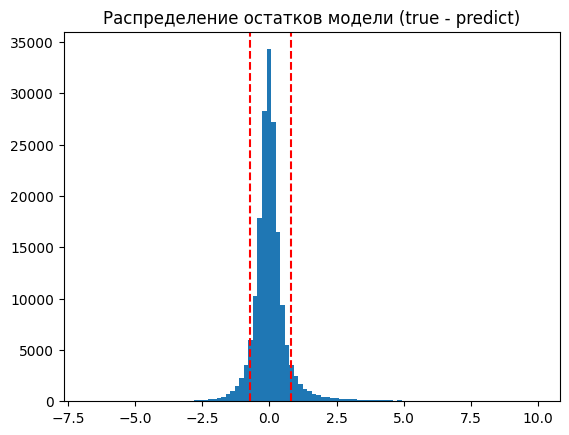

In [ ]:
params_ridge = {
    "alpha" : 0.0010155516206526586
}
ridge_model = Ridge(**params_ridge)
visual_model_predict(ridge_model, data=data.drop(columns=["time_jog", "last_time_jog_pace"]))

In [ ]:
joblib.dump(ridge_model, "/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_ridge_by_distance.pkl")

['/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_ridge_by_distance.pkl']

RMSE: 0.7897
MAE: 0.4413
R² 0.5238
Процент заключенный в 1 сигме 86.361
Среднее остатков: 0.040
Стандартное отклонение остатков: 0.789
Коэффициент ассиметрии: 23.875
Коэффициент эксцесса: 3.041
P-value теста Пирсона: 0.000


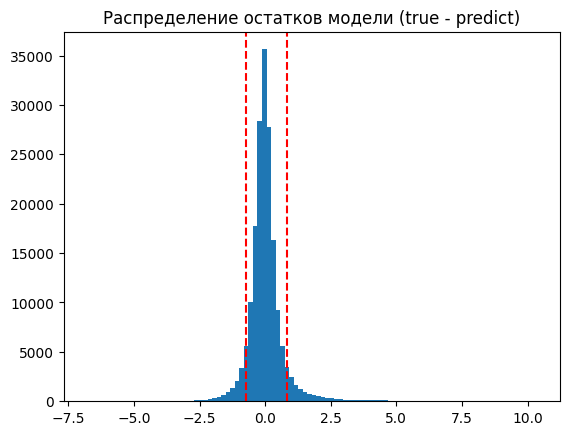

In [ ]:
params_ridge = {
    "alpha" : 9927.647230908844
}
ridge_model = Ridge(**params_ridge)
visual_model_predict(ridge_model, data=data.drop(columns=["last_distance_pace", "distance"]))

In [ ]:
joblib.dump(ridge_model, "/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_ridge_by_time.pkl")

['/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_ridge_by_time.pkl']

###Подбор alpha

In [ ]:
def objective(trial, data):
    """

    """
    alpha = trial.suggest_float("alpha", 1e-3, 1e4, log=True)

    reg_model = Ridge(alpha=alpha)
    _, _, rmse, _, _ = train_test_split_ts(reg_model, data, test_percent=test_percent)

    return rmse

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
        seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, data=data.drop(columns=["last_time_jog_pace", "time_jog"])),
                n_trials=50
               )

/tmp/ipykernel_11916/447512837.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_11916/447512837.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-04-20 15:35:44,760] A new study created in memory with name: no-name-ce4c19d8-7a0d-4984-8462-4e9a7d9a5c26


start!


[I 2026-04-20 15:36:22,821] Trial 0 finished with value: 0.7795395380172956 and parameters: {'alpha': 0.4185822729546973}. Best is trial 0 with value: 0.7795395380172956.
[I 2026-04-20 15:36:44,122] Trial 1 finished with value: 0.7795406060023061 and parameters: {'alpha': 4518.56095102411}. Best is trial 0 with value: 0.7795395380172956.
[I 2026-04-20 15:37:06,626] Trial 2 finished with value: 0.7795395642964674 and parameters: {'alpha': 133.03245101522916}. Best is trial 0 with value: 0.7795395380172956.
[I 2026-04-20 15:37:29,794] Trial 3 finished with value: 0.7795395409921826 and parameters: {'alpha': 15.509913987594315}. Best is trial 0 with value: 0.7795395380172956.
[I 2026-04-20 15:37:52,542] Trial 4 finished with value: 0.7795395379372749 and parameters: {'alpha': 0.012363188277052215}. Best is trial 4 with value: 0.7795395379372749.
[I 2026-04-20 15:38:14,562] Trial 5 finished with value: 0.779539537937274 and parameters: {'alpha': 0.012358382772306926}. Best is trial 5 with 

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
        seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, data=data.drop(columns=["last_distance_pace", "distance"])),
                n_trials=50
               )

/tmp/ipykernel_11916/3683158726.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_11916/3683158726.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-04-20 15:54:34,224] A new study created in memory with name: no-name-1a6ddbce-c074-4f1d-a70f-3346be9c4c79


start!


[I 2026-04-20 15:54:55,196] Trial 0 finished with value: 0.7896899417605485 and parameters: {'alpha': 0.4185822729546973}. Best is trial 0 with value: 0.7896899417605485.
[I 2026-04-20 15:55:17,630] Trial 1 finished with value: 0.7896845060566817 and parameters: {'alpha': 4518.56095102411}. Best is trial 1 with value: 0.7896845060566817.
[I 2026-04-20 15:55:39,351] Trial 2 finished with value: 0.7896897768803796 and parameters: {'alpha': 133.03245101522916}. Best is trial 1 with value: 0.7896845060566817.
[I 2026-04-20 15:56:01,859] Trial 3 finished with value: 0.7896899229808857 and parameters: {'alpha': 15.509913987594315}. Best is trial 1 with value: 0.7896845060566817.
[I 2026-04-20 15:56:23,064] Trial 4 finished with value: 0.7896899422661061 and parameters: {'alpha': 0.012363188277052215}. Best is trial 1 with value: 0.7896845060566817.
[I 2026-04-20 15:56:45,916] Trial 5 finished with value: 0.7896899422661122 and parameters: {'alpha': 0.012358382772306926}. Best is trial 1 with

##Пуассоновская регрессия

RMSE: 0.7875
MAE: 0.4473
R² 0.5264
Процент заключенный в 1 сигме 86.368
Среднее остатков: 0.043
Стандартное отклонение остатков: 0.786
Коэффициент ассиметрии: 23.171
Коэффициент эксцесса: 2.658
P-value теста Пирсона: 0.000


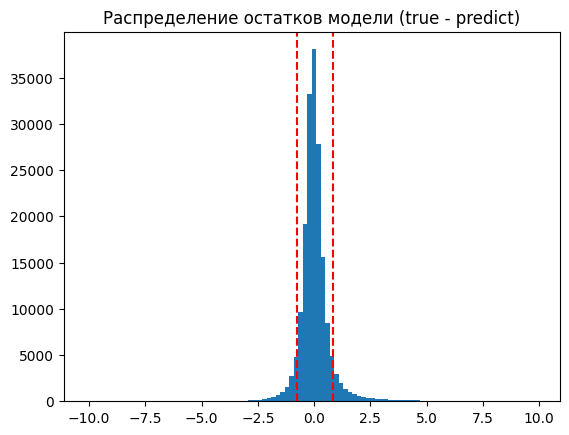

In [ ]:
poisson_reg_params = {
    "alpha" : 1e-4
}
poisson_reg_model = PoissonRegressor(**poisson_reg_params)
visual_model_predict(poisson_reg_model, data=data.drop(columns=["last_time_jog_pace", "time_jog"]))

###Grid Search для alpha

In [ ]:
for alpha in [10**i for i in range(-7, 5)]:
    model = PoissonRegressor(alpha=alpha)
    _, _, rmse, mae, r2 = train_test_split_ts(model, df=data.drop(columns=["last_time_jog_pace", "time_jog"]), test_percent=test_percent, target="pace")
    print("*"*20)
    print(f"alpha = {alpha}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R\u00B2: {r2}")

********************
alpha = 1e-07
RMSE: 0.787530210374587
MAE: 0.4472478324291821
R²: 0.5264019217344215
********************
alpha = 1e-06
RMSE: 0.7875340908933901
MAE: 0.44725388261291393
R²: 0.5263972544575312
********************
alpha = 1e-05
RMSE: 0.7875334260155848
MAE: 0.44725686264009606
R²: 0.5263980541380142
********************
alpha = 0.0001
RMSE: 0.7875193037768475
MAE: 0.44726920771990514
R²: 0.5264150394736372


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


********************
alpha = 0.001
RMSE: 0.78751402869663
MAE: 0.4473364336244759
R²: 0.5264213839283769


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


********************
alpha = 0.01
RMSE: 0.7871944367247077
MAE: 0.4479567585978295
R²: 0.526805684924033


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


********************
alpha = 0.1
RMSE: 0.7875650695704328
MAE: 0.4473387469544111
R²: 0.5263599941656064
********************
alpha = 1
RMSE: 0.7884407863306464
MAE: 0.44932502735931845
R²: 0.5253061000623036
********************
alpha = 10
RMSE: 0.8040800258218238
MAE: 0.4695266517072525
R²: 0.50628760128386
********************
alpha = 100
RMSE: 0.9577145136417822
MAE: 0.6065978144814279
R²: 0.29959760256857804
********************
alpha = 1000
RMSE: 1.1125085426021393
MAE: 0.7345223745515386
R²: 0.05489035552254795
********************
alpha = 10000
RMSE: 1.14288254270846
MAE: 0.7599803050524176
R²: 0.0025785950639615196


##XGBRegressor

RMSE: 0.7556
MAE: 0.4164
R² 0.5640
Процент заключенный в 1 сигме 86.694
Среднее остатков: 0.037
Стандартное отклонение остатков: 0.755
Коэффициент ассиметрии: 26.101
Коэффициент эксцесса: 3.125
P-value теста Пирсона: 0.000


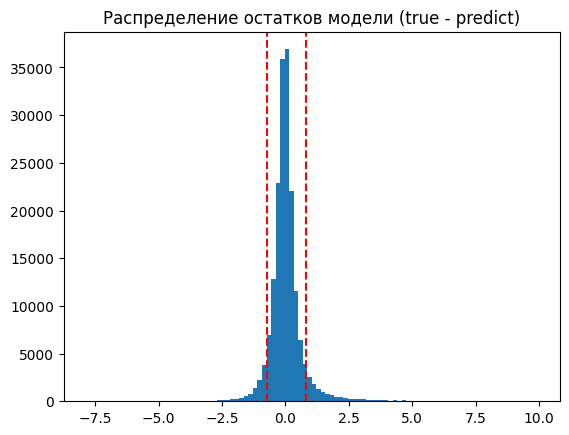

In [ ]:
params_xgb = {
    "objective": "reg:squarederror",
    "n_estimators" : 2000,
    "max_depth" : 10,
    "learning_rate" : 0.0071144760093434225,
    "reg_alpha" : 8.471801418819979,
    "reg_lambda" : 2.481040974867813,
    "subsample" :  0.7390046601106091,
    "colsample_bytree" : 0.7389986300840506,
    "tree_method" : "hist",
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}
xgb_model = xgb.XGBRegressor(**params_xgb)
visual_model_predict(xgb_model, data=data.drop(columns=["last_time_jog_pace", "time_jog"]))

In [ ]:
joblib.dump(xgb_model, "/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_xgb_by_distance.pkl")

['/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_xgb_by_distance.pkl']

RMSE: 0.7748
MAE: 0.4189
R² 0.5416
Процент заключенный в 1 сигме 87.235
Среднее остатков: 0.039
Стандартное отклонение остатков: 0.774
Коэффициент ассиметрии: 27.348
Коэффициент эксцесса: 3.461
P-value теста Пирсона: 0.000


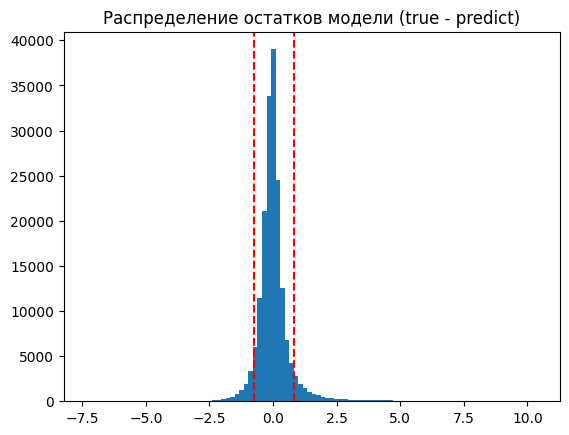

In [ ]:
params_xgb = {
    "objective": "reg:squarederror",
    "n_estimators" : 2000,
    "max_depth" : 8,
    "learning_rate" : 0.00692445969893463,
    "reg_alpha" : 15.661487448094318,
    "reg_lambda" : 0.051281577804429365,
    "subsample" :  0.8514064699632077,
    "colsample_bytree" : 0.7410013737186606,
    "tree_method" : "hist",
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}
xgb_model = xgb.XGBRegressor(**params_xgb)
visual_model_predict(xgb_model, data=data.drop(columns=["last_distance_pace", "distance"]))

In [ ]:
joblib.dump(xgb_model, "/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_xgb_by_time.pkl")

['/content/drive/MyDrive/ML_data/jog_ml/ml_models/model_covid_dataset_xgb_by_time.pkl']

###Подбор параметров для XGB

In [ ]:
def objective(trial, data):
    """

    """
    objective = trial.suggest_categorical("objective", ["reg:squarederror"])
    max_depth = trial.suggest_int("max_depth", 6, 14)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    n_estimators = 2000#trial.suggest_int("n_estimators", 100, 650)
    reg_alpha = trial.suggest_float("reg_alpha", 0.01, 100, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 0.01, 100, log=True)
    subsample = trial.suggest_float("subsample", 0.7, 0.95)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.7, 0.95)


    params={
        'objective': objective,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'subsample': subsample,
        'colsample_bytree': 1,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'random_state': 42,
        'tree_method' : 'hist',
        'device': "cuda" if torch.cuda.is_available() else "cpu"
      }

    xgb_model = xgb.XGBRegressor(**params)
    _, _, rmse, _, _ = train_test_split_ts(xgb_model, data, test_percent=test_percent)

    return rmse

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=8,
        seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, data=data.drop(columns=["last_time_jog_pace", "time_jog"])),
                n_trials=30
               )

/tmp/ipykernel_3679/1443012055.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_3679/1443012055.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-04-18 17:44:23,226] A new study created in memory with name: no-name-826d7e4c-9ab4-45c9-a812-02225bedc9d1


start!


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:45:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-04-18 17:45:52,895] Trial 0 finished with value: 0.7558993742269704 and parameters: {'objective': 'reg:squarederror', 'max_depth': 10, 'learning_rate': 0.0071144760093434225, 'reg_alpha': 8.471801418819979, 'reg_lambda': 2.481040974867813, 'subsample': 0.7390046601106091, 'colsample_bytree': 0.7389986300840506}. Best is trial 0 with value: 0.7558993742269704.
[I 2026-04-18 17:47:07,741] Trial 1 finished with value: 0.7564604943438793

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
        seed=42,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, data=data.drop(columns=["last_distance_pace", "distance"])),
                n_trials=50
               )

/tmp/ipykernel_1354/3683158726.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_1354/3683158726.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-04-21 07:43:37,298] A new study created in memory with name: no-name-c41f25e4-3b53-4fbe-a970-058199c521b5


start!


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [07:44:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-04-21 07:44:54,811] Trial 0 finished with value: 0.7749008475777737 and parameters: {'objective': 'reg:squarederror', 'max_depth': 9, 'learning_rate': 0.0071144760093434225, 'reg_alpha': 8.471801418819979, 'reg_lambda': 2.481040974867813, 'subsample': 0.7390046601106091, 'colsample_bytree': 0.7389986300840506}. Best is trial 0 with value: 0.7749008475777737.
[I 2026-04-21 07:45:51,317] Trial 1 finished with value: 0.7766033960121432 

##RandomForest

RMSE: 0.7648
MAE: 0.4247
R² 0.5534
Процент заключенный в 1 сигме 86.179
Среднее остатков: 0.034
Стандартное отклонение остатков: 0.764
Коэффициент ассиметрии: 25.388
Коэффициент эксцесса: 3.228
P-value теста Пирсона: 0.000


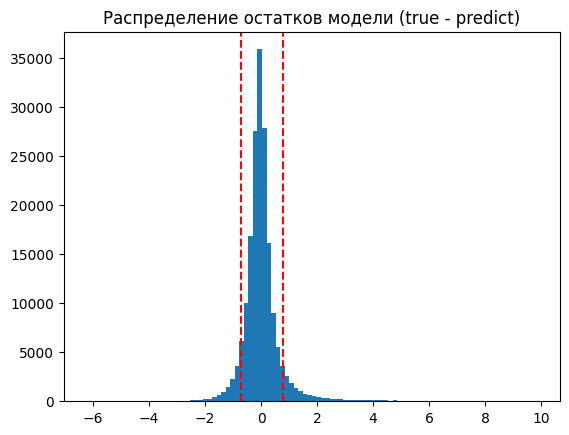

In [ ]:
rf_params = {
    "n_estimators" : 100,
    "max_depth" : 6
}
rf_model = RandomForestRegressor(**rf_params)
visual_model_predict(rf_model)

##KNN

RMSE: 0.7781
MAE: 0.4353
R² 0.5377
Процент заключенный в 1 сигме 86.240
Среднее остатков: 0.048
Стандартное отклонение остатков: 0.777
Коэффициент ассиметрии: 24.366
Коэффициент эксцесса: 3.015
P-value теста Пирсона: 0.000


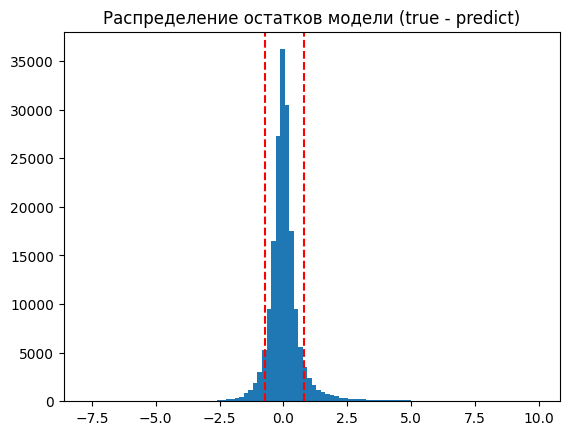

In [ ]:
knn_param = {
    "n_neighbors": 15
}
knn_model = KNeighborsRegressor(**knn_param)
visual_model_predict(knn_model, data=data.drop(columns=["last_time_jog_pace", "time_jog"]))

##TabM

In [ ]:
!pip install pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytabkit/models/nn_models/rtdl_num_embeddings.py:311: UserWarning: The 1-th feature has just two bin edges, which means only one bin. Strictly speaking, using a single bin for the piecewise-linear encoding should not break anything, but it is the same as using sklearn.preprocessing.MinMaxScaler
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytabkit/models/nn_models/rtdl_num_embeddings.py:311: UserWarning: The 13-th feature has just two bin edges, which means only one bin. Strictly speaking, using a single bin for the piecewise-linear encoding should not

RMSE: 0.7622
MAE: 0.4261
R² 0.5564
Процент заключенный в 1 сигме 86.898
Среднее остатков: 0.022
Стандартное отклонение остатков: 0.762
Коэффициент ассиметрии: 25.630
Коэффициент эксцесса: 3.292
P-value теста Пирсона: 0.000


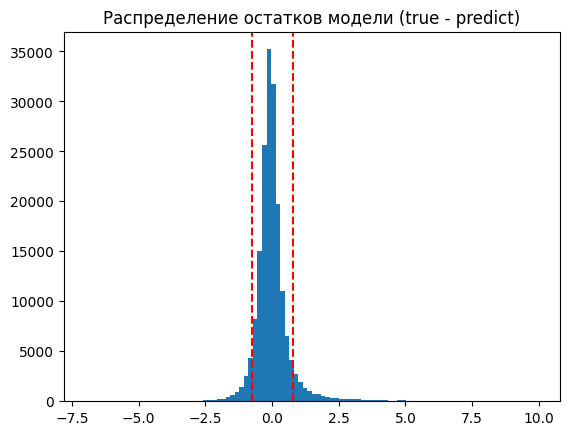

In [ ]:
from pytabkit import TabM_D_Regressor

tabm_params = {
    'batch_size': 'auto',
    'patience': 16,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 8,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.0029993695720154537,
    'weight_decay': 0.08742083301699905,
    'n_blocks': 3,
    'd_block': 32,
    'dropout': 0.1,
    'num_emb_type': 'pwl',
    'd_embedding': 32,
    'num_emb_n_bins': 150,
    'device': "cuda" if torch.cuda.is_available() else "cpu"
}

model_tabm = TabM_D_Regressor(**tabm_params)
visual_model_predict(model_tabm, data=data.drop(columns=["last_time_jog_pace", "time_jog"]))